# Marketing Experiment & Incrementality Analysis

## Business Question

Does exposure to an advertising campaign generate incremental conversions compared with a PSA control group, and is the observed lift large enough to justify continued investment?

## Experiment Design

Users were assigned to one of two experimental conditions:

- **Treatment (`ad`)** — users assigned to the advertising campaign
- **Control (`psa`)** — users assigned to a public service announcement instead

The primary outcome is whether a user converted.

The analysis follows four stages:

1. Validate the experiment data and treatment allocation
2. Estimate the conversion-rate treatment effect
3. Translate the effect into incremental conversions and business break-even scenarios
4. Explore exposure-frequency and timing patterns as descriptive follow-up analyses

The ad-vs.-PSA comparison is treated as the experimental contrast. Exposure frequency and timing variables occur after assignment and are therefore interpreted descriptively rather than as independently randomized treatments.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from statsmodels.stats.proportion import (
    proportions_ztest,
    confint_proportions_2indep
)

## 1. Data Preparation & Validation

Before estimating the treatment effect, the dataset is checked for structural issues that could undermine the analysis, including missing values, duplicate users, invalid categories, and unexpected numeric ranges.

In [40]:
# Load the raw experiment data.
df = pd.read_csv("../data/raw/marketing_AB.csv")

df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [41]:
# Remove the exported CSV index if it is present.
# errors="ignore" keeps the cell safe to rerun.
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.columns

Index(['user id', 'test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='str')

In [43]:
# Inspect dataset dimensions, column types, and non-null counts.
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 588,101
Columns: 6
<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user id        588101 non-null  int64
 1   test group     588101 non-null  str  
 2   converted      588101 non-null  bool 
 3   total ads      588101 non-null  int64
 4   most ads day   588101 non-null  str  
 5   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(3), str(2)
memory usage: 23.0 MB


In [44]:
# Check whether any fields contain missing values.
missing_values = df.isna().sum()

missing_values

user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [45]:
# Confirm that each row represents one unique user.
print(f"Total rows: {len(df):,}")
print(f"Unique users: {df['user id'].nunique():,}")
print(f"Duplicate user IDs: {df['user id'].duplicated().sum():,}")

Total rows: 588,101
Unique users: 588,101
Duplicate user IDs: 0


In [46]:
# Inspect categorical values for unexpected labels.
for col in ["test group", "converted", "most ads day"]:
    print(f"\n{col}:")
    display(df[col].value_counts(dropna=False))


test group:


test group
ad     564577
psa     23524
Name: count, dtype: int64


converted:


converted
False    573258
True      14843
Name: count, dtype: int64


most ads day:


most ads day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64

In [47]:
# Check that exposure counts and hours fall within plausible ranges.
print(f"Minimum total ads: {df['total ads'].min():,}")
print(f"Maximum total ads: {df['total ads'].max():,}")

print(f"Minimum hour: {df['most ads hour'].min()}")
print(f"Maximum hour: {df['most ads hour'].max()}")

Minimum total ads: 1
Maximum total ads: 2,065
Minimum hour: 0
Maximum hour: 23


### Data Validation Summary

The dataset contains **588,101 user-level observations** with one record per user.

- No duplicate user IDs were identified.
- No missing values were identified.
- Both experimental conditions are represented.
- The conversion field is stored as a Boolean outcome.
- Exposure-hour values fall within the expected 24-hour range.

The dataset is therefore suitable for the primary treatment-versus-control comparison.

In [48]:
# Examine treatment-group sizes and allocation shares.
allocation = pd.DataFrame({
    "users": df["test group"].value_counts(),
    "share_pct": df["test group"].value_counts(normalize=True) * 100
})

allocation

,users,share_pct
test group,,
ad,564577,96.000007
psa,23524,3.999993


### Treatment Allocation

The experiment has a highly unequal allocation: approximately **96% of users are in the advertising group and 4% are in the PSA control group**.

This imbalance is important to document, but it does not by itself establish a randomization failure. A sample-ratio-mismatch test requires a known expected allocation ratio, and the intended treatment probability is not provided with the dataset. Therefore, no assumption of a 50/50 allocation is made.

The PSA group still contains more than **23,000 users**, providing a substantial control sample for estimating conversion-rate differences.

In [49]:
# Save a cleaned copy for SQL analysis and reproducibility.
df.to_csv("../data/processed/marketing_ab_clean.csv", index=False)

## 2. Primary Experiment Analysis

### Primary Metric

The primary metric is **conversion rate**, defined as the proportion of users who converted within each experimental group.

The treatment effect will be summarized using:

- **Absolute lift:** Difference in conversion rates between ad and PSA
- **Relative lift:** Percentage improvement relative to the PSA baseline
- **95% confidence interval:** Range of plausible values for the conversion-rate difference
- **Statistical significance:** Evidence against equal conversion rates

### Hypotheses

**Null hypothesis (H₀):** The conversion rate is the same for users assigned to the advertising and PSA conditions.

**Alternative hypothesis (H₁):** The conversion rates differ between the advertising and PSA conditions.

A significance level of **α = 0.05** is used.

A two-sided hypothesis is used rather than assuming in advance that advertising must improve conversion.

Statistical significance alone will not determine the business recommendation. Effect magnitude, uncertainty, and campaign economics will also be considered.

In [50]:
# Summarize sample size, conversions, and conversion rate by condition.
group_summary = (
    df.groupby("test group")
      .agg(
          users=("user id", "count"),
          conversions=("converted", "sum"),
          conversion_rate=("converted", "mean")
      )
)

group_summary["conversion_rate_pct"] = (
    group_summary["conversion_rate"] * 100
)

group_summary

,users,conversions,conversion_rate,conversion_rate_pct
test group,,,,
ad,564577,14423,0.025547,2.554656
psa,23524,420,0.017854,1.785411


In [51]:
# Calculate the observed treatment-control difference.
ad_rate = df.loc[df["test group"] == "ad", "converted"].mean()
psa_rate = df.loc[df["test group"] == "psa", "converted"].mean()

absolute_lift = ad_rate - psa_rate
relative_lift = absolute_lift / psa_rate

print(f"Ad conversion rate:       {ad_rate:.3%}")
print(f"PSA conversion rate:      {psa_rate:.3%}")
print(f"Absolute lift:            {absolute_lift:.3%}")
print(f"Relative lift:            {relative_lift:.1%}")

Ad conversion rate:       2.555%
PSA conversion rate:      1.785%
Absolute lift:            0.769%
Relative lift:            43.1%


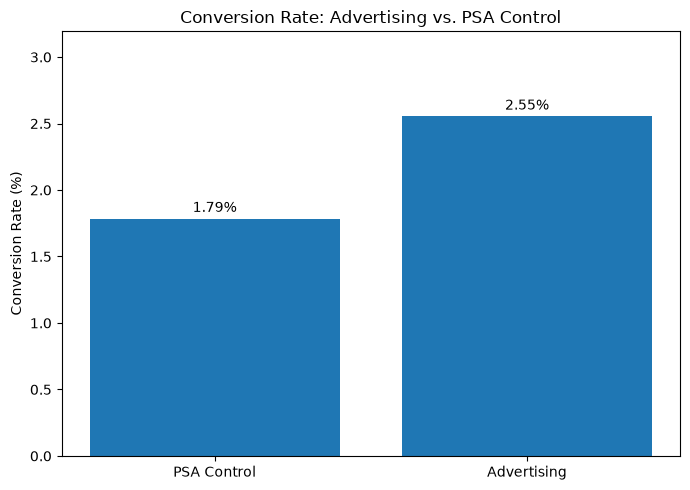

In [52]:
# Visualize the experiment's primary outcome before moving into
# secondary exploratory analyses.
conversion_plot = (
    group_summary
    .loc[["psa", "ad"], "conversion_rate_pct"]
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["PSA Control", "Advertising"],
    conversion_plot.values
)

plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate: Advertising vs. PSA Control")

for bar, value in zip(bars, conversion_plot.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, conversion_plot.max() * 1.25)
plt.tight_layout()
plt.show()

In [53]:
# Extract conversion counts and group sizes for the two-proportion test.
ad_conversions = df.loc[
    df["test group"] == "ad", "converted"
].sum()

psa_conversions = df.loc[
    df["test group"] == "psa", "converted"
].sum()

ad_n = (df["test group"] == "ad").sum()
psa_n = (df["test group"] == "psa").sum()

count = np.array([
    ad_conversions,
    psa_conversions
])

nobs = np.array([
    ad_n,
    psa_n
])

# Test whether the observed conversion-rate difference is
# inconsistent with the null hypothesis of equal conversion rates.
z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided"
)

# Estimate uncertainty around the absolute difference: ad - PSA.
# With these very large samples, the Wald interval is sufficiently stable
# for this descriptive experiment readout.
ci_low, ci_high = confint_proportions_2indep(
    count1=ad_conversions,
    nobs1=ad_n,
    count2=psa_conversions,
    nobs2=psa_n,
    method="wald",
    compare="diff",
    alpha=0.05
)

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.6g}")

print(
    f"95% CI for absolute lift: "
    f"[{ci_low * 100:.3f}, {ci_high * 100:.3f}] percentage points"
)

Z-statistic: 7.370
P-value: 1.70528e-13
95% CI for absolute lift: [0.595, 0.943] percentage points


### Statistical Interpretation

The advertising group achieved a **2.555% conversion rate**, compared with **1.785% for the PSA control group**.

This corresponds to:

- **0.769 percentage points of absolute lift**
- **43.1% relative lift**

The two-proportion z-test produced a **z-statistic of 7.37** and a **p-value < 0.001**, providing strong evidence against the null hypothesis of equal conversion rates.

The **95% confidence interval for absolute lift is 0.595 to 0.943 percentage points**. Because the entire interval is above zero, the observed evidence is consistent with a positive advertising treatment effect.

However, statistical significance alone does not establish whether the campaign was economically worthwhile. The treatment effect must also be translated into business impact.

In [54]:
# Use the PSA conversion rate as the control-rate counterfactual:
# how many ad-group conversions would be expected if those users
# converted at the control-group rate?
expected_conversions_at_control_rate = (
    ad_n * psa_rate
)

incremental_conversions = (
    ad_conversions
    - expected_conversions_at_control_rate
)

# Propagate the treatment-effect confidence interval into an
# estimated range of incremental conversions.
incremental_low = ad_n * ci_low
incremental_high = ad_n * ci_high

print(
    f"Observed ad conversions: "
    f"{ad_conversions:,.0f}"
)

print(
    f"Expected conversions at PSA rate: "
    f"{expected_conversions_at_control_rate:,.0f}"
)

print(
    f"Estimated incremental conversions: "
    f"{incremental_conversions:,.0f}"
)

print(
    f"95% CI for incremental conversions: "
    f"{incremental_low:,.0f} to {incremental_high:,.0f}"
)

Observed ad conversions: 14,423
Expected conversions at PSA rate: 10,080
Estimated incremental conversions: 4,343
95% CI for incremental conversions: 3,360 to 5,326


### Estimated Incremental Conversions

If users assigned to advertising had converted at the PSA control rate, approximately **10,080 conversions** would have been expected.

Instead, **14,423 conversions** were observed.

Applying the estimated treatment effect to the advertising group suggests approximately **4,343 incremental conversions**, with a plausible range of roughly **3,360 to 5,326 additional conversions** based on the 95% confidence interval.

Incremental conversions provide a more business-interpretable measure than the p-value alone. However, the dataset does not contain advertising cost or value-per-conversion information, so this result cannot by itself establish profitability.

## 3. Business Significance & Break-Even Analysis

A statistically significant conversion lift does not necessarily imply that the advertising campaign was profitable.

The dataset does not contain:

- Campaign cost
- Revenue per conversion
- Contribution margin per conversion

Instead of inventing a single ROI assumption, a **sensitivity analysis** is used.

For different hypothetical values per incremental conversion, the analysis calculates the maximum total campaign cost at which the estimated incremental value would equal campaign cost.

In [55]:
# Evaluate campaign economics across a range of possible
# business values per incremental conversion.
conversion_values = np.array([
    10, 25, 50, 75, 100, 150, 200
])

break_even = pd.DataFrame({
    "value_per_incremental_conversion":
        conversion_values
})

break_even[
    "estimated_break_even_campaign_cost"
] = (
    break_even["value_per_incremental_conversion"]
    * incremental_conversions
)

break_even[
    "conservative_break_even_campaign_cost"
] = (
    break_even["value_per_incremental_conversion"]
    * incremental_low
)

break_even[
    "optimistic_break_even_campaign_cost"
] = (
    break_even["value_per_incremental_conversion"]
    * incremental_high
)

break_even

,value_per_incremental_conversion,estimated_break_even_campaign_cost,conservative_break_even_campaign_cost,optimistic_break_even_campaign_cost
0,10,43429.821459,33597.595794,5.326205e+04
1,25,108574.553647,83993.989486,1.331551e+05
2,50,217149.107295,167987.978972,2.663102e+05
3,75,325723.660942,251981.968458,3.994654e+05
4,100,434298.214589,335975.957944,5.326205e+05
5,150,651447.321884,503963.936916,7.989307e+05
6,200,868596.429179,671951.915888,1.065241e+06


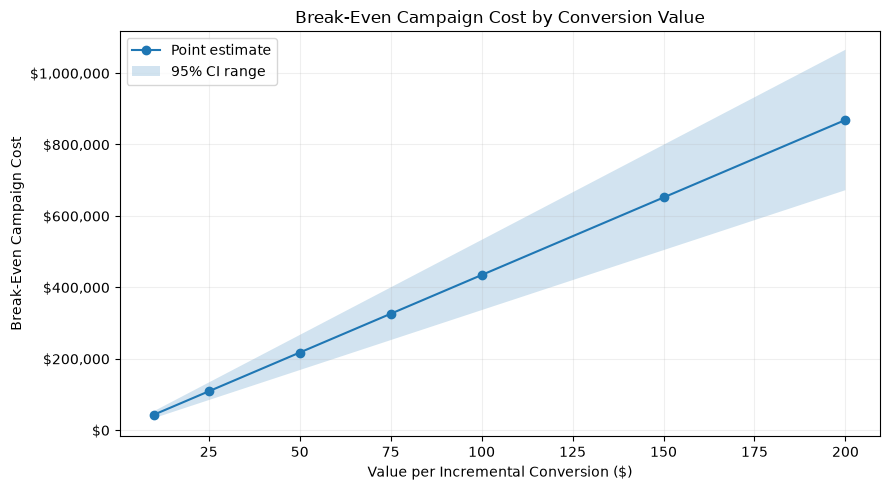

In [56]:
# Show how the campaign's break-even threshold changes with
# the assumed value of an incremental conversion.
plt.figure(figsize=(9, 5))

plt.plot(
    break_even["value_per_incremental_conversion"],
    break_even["estimated_break_even_campaign_cost"],
    marker="o",
    label="Point estimate"
)

plt.fill_between(
    break_even["value_per_incremental_conversion"],
    break_even["conservative_break_even_campaign_cost"],
    break_even["optimistic_break_even_campaign_cost"],
    alpha=0.2,
    label="95% CI range"
)

plt.xlabel("Value per Incremental Conversion ($)")
plt.ylabel("Break-Even Campaign Cost")
plt.title("Break-Even Campaign Cost by Conversion Value")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Business Interpretation

Whether the campaign is economically attractive depends on the value generated by each incremental conversion relative to the total campaign cost.

For example, if an incremental conversion contributes **$100 in business value**, the point estimate of 4,343 incremental conversions implies a break-even campaign cost of approximately **$434,000**.

Using the lower bound of the treatment-effect confidence interval gives a more conservative break-even threshold of approximately **$336,000**.

Therefore:

- If actual campaign costs are comfortably below the relevant break-even threshold, the experimental evidence supports continued investment.
- If campaign costs exceed the threshold, the statistically significant conversion lift may still be economically insufficient.

This sensitivity analysis translates the experiment into a business decision without presenting assumed financial values as observed data.

## 4. Ad Exposure Frequency Analysis

The experiment establishes the primary comparison between assignment to advertising and assignment to PSA.

The dataset also contains `total ads`, representing the number of exposures accumulated by each user.

Unlike the original experimental assignment, exposure frequency was not independently randomized. Users with greater exposure may differ systematically in engagement, time on platform, or opportunity to convert.

For that reason, exposure-frequency results are interpreted as **descriptive associations rather than causal effects**.

In [57]:
# Inspect exposure-frequency distributions in both groups.
df.groupby("test group")["total ads"].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
test group,,,,,,,,,,,
ad,564577.0,24.823365,43.750456,1.0,4.0,13.0,27.0,56.0,87.00,201.0,2065.0
psa,23524.0,24.761138,42.860720,1.0,4.0,12.0,26.0,59.0,92.85,206.0,907.0


In [58]:
ad_users = df[
    df["test group"] == "ad"
].copy()

p99 = ad_users["total ads"].quantile(0.99)

print(
    f"99th percentile of ad exposure: "
    f"{p99:.0f}"
)

print(
    f"Maximum ad exposure: "
    f"{ad_users['total ads'].max():,}"
)

99th percentile of ad exposure: 201
Maximum ad exposure: 2,065


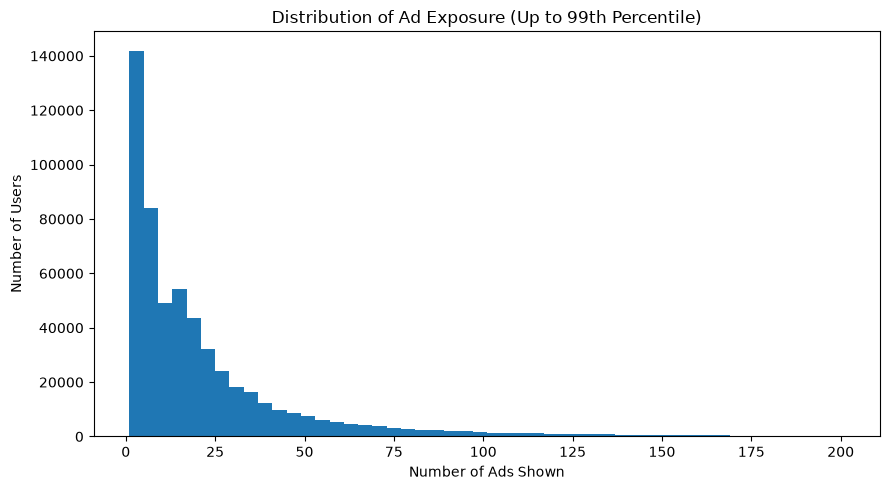

In [59]:
# Limit the histogram to the 99th percentile so extreme
# exposures do not obscure the distribution for most users.
plt.figure(figsize=(9, 5))

plt.hist(
    ad_users.loc[
        ad_users["total ads"] <= p99,
        "total ads"
    ],
    bins=50
)

plt.xlabel("Number of Ads Shown")
plt.ylabel("Number of Users")
plt.title(
    "Distribution of Ad Exposure "
    "(Up to 99th Percentile)"
)

plt.tight_layout()
plt.show()

In [60]:
# Create business-readable exposure ranges.
# These bins are used for descriptive comparison only;
# they do not represent randomized treatment levels.
exposure_bins = [
    0, 5, 10, 20, 30,
    50, 100, 200, np.inf
]

exposure_labels = [
    "1–5",
    "6–10",
    "11–20",
    "21–30",
    "31–50",
    "51–100",
    "101–200",
    "201+"
]

comparison_df = df.copy()

comparison_df["exposure_band"] = pd.cut(
    comparison_df["total ads"],
    bins=exposure_bins,
    labels=exposure_labels
)

exposure_group_summary = (
    comparison_df
    .groupby(
        ["exposure_band", "test group"],
        observed=True
    )
    .agg(
        users=("user id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

exposure_group_summary[
    "conversion_rate_pct"
] = (
    exposure_group_summary["conversion_rate"]
    * 100
)

exposure_group_summary

,exposure_band,test group,users,conversions,conversion_rate,conversion_rate_pct
0,1–5,ad,169962,427,0.002512,0.251233
1,1–5,psa,7861,22,0.002799,0.279863
2,6–10,ad,79537,386,0.004853,0.485309
3,6–10,psa,3415,23,0.006735,0.673499
4,11–20,ad,123334,1036,0.008400,0.839995
5,11–20,psa,4150,34,0.008193,0.819277
6,21–30,ad,66150,1177,0.017793,1.779289
7,21–30,psa,2972,46,0.015478,1.547779
8,31–50,ad,59391,2483,0.041808,4.180768
9,31–50,psa,2263,68,0.030049,3.004861


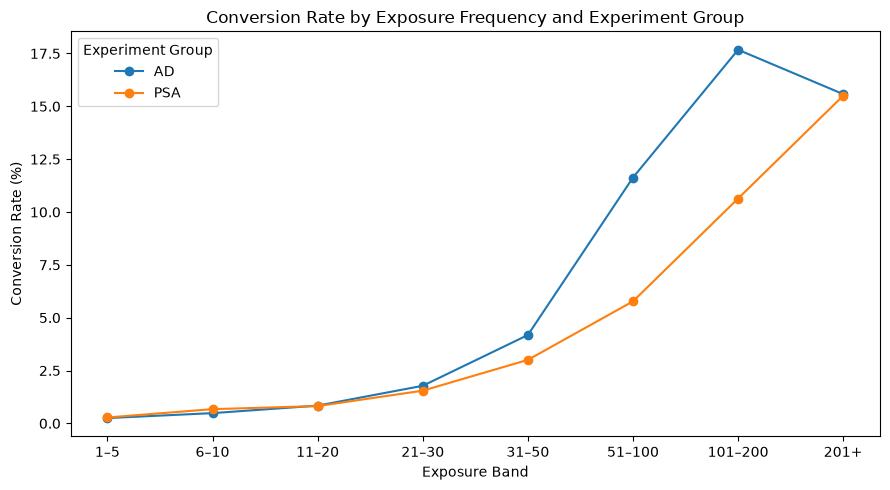

In [61]:
# Compare conversion patterns across the same exposure bands
# in both experimental groups.
plt.figure(figsize=(9, 5))

for group in ["ad", "psa"]:
    subset = exposure_group_summary[
        exposure_group_summary["test group"]
        == group
    ]

    plt.plot(
        subset["exposure_band"].astype(str),
        subset["conversion_rate_pct"],
        marker="o",
        label=group.upper()
    )

plt.xlabel("Exposure Band")
plt.ylabel("Conversion Rate (%)")

plt.title(
    "Conversion Rate by Exposure Frequency "
    "and Experiment Group"
)

plt.legend(title="Experiment Group")

plt.tight_layout()
plt.show()

### Exposure Frequency Interpretation

Conversion rates increased substantially with observed exposure frequency in **both experimental groups**.

Among advertising users, conversion increased from approximately **0.25% at 1–5 exposures** to **17.68% at 101–200 exposures**.

However, a similar relationship appears in the PSA control group, where conversion increased from approximately **0.28% to 10.64%** across the same ranges.

The fact that conversion rises with exposure in both groups suggests that exposure count is also capturing underlying user behavior or opportunity to convert. Users who accumulate many exposures may be more active, return more often, or simply have more opportunities both to encounter campaign content and to convert.

Therefore, the exposure-frequency analysis does **not** establish that showing more ads causes higher conversion.

Likewise, the decline beyond 200 exposures is insufficient evidence of a causal saturation point or an optimal frequency cap.

A separate experiment that randomizes exposure frequency would be required to estimate the causal effect of additional exposures.

## 5. Campaign Timing Analysis

The dataset also records the day and hour when each user received the greatest number of exposures.

These variables can reveal behavioral patterns, but exposure timing was not independently randomized.

Timing results are therefore treated as **hypothesis-generating descriptive evidence**, not as causal estimates of when advertising is most effective.

In [62]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_summary = (
    df.groupby(
        ["most ads day", "test group"],
        observed=True
    )
    .agg(
        users=("user id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

day_summary["conversion_rate_pct"] = (
    day_summary["conversion_rate"] * 100
)

day_summary["most ads day"] = pd.Categorical(
    day_summary["most ads day"],
    categories=day_order,
    ordered=True
)

day_summary = day_summary.sort_values(
    ["most ads day", "test group"]
)

day_summary

,most ads day,test group,users,conversions,conversion_rate,conversion_rate_pct
2,Monday,ad,83571,2778,0.033241,3.324120
3,Monday,psa,3502,79,0.022559,2.255854
10,Tuesday,ad,74572,2270,0.030440,3.044038
11,Tuesday,psa,2907,42,0.014448,1.444788
12,Wednesday,ad,77418,1963,0.025356,2.535586
13,Wednesday,psa,3490,55,0.015759,1.575931
8,Thursday,ad,79077,1711,0.021637,2.163714
9,Thursday,psa,3905,79,0.020230,2.023047
0,Friday,ad,88805,1995,0.022465,2.246495
1,Friday,psa,3803,62,0.016303,1.630292


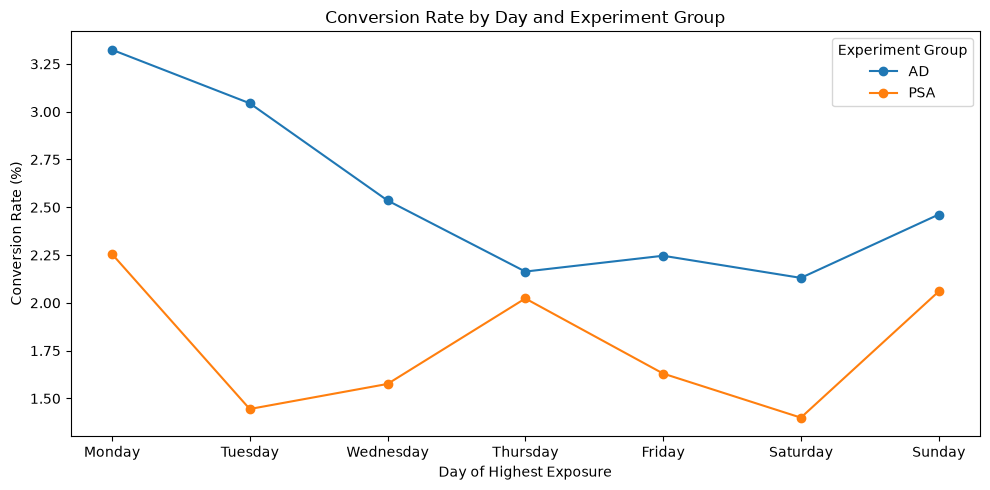

In [63]:
plt.figure(figsize=(10, 5))

for group in ["ad", "psa"]:
    subset = day_summary[
        day_summary["test group"] == group
    ]

    plt.plot(
        subset["most ads day"].astype(str),
        subset["conversion_rate_pct"],
        marker="o",
        label=group.upper()
    )

plt.xlabel("Day of Highest Exposure")
plt.ylabel("Conversion Rate (%)")

plt.title(
    "Conversion Rate by Day "
    "and Experiment Group"
)

plt.legend(title="Experiment Group")

plt.tight_layout()
plt.show()

### Day-of-Week Patterns

The advertising group had a higher observed conversion rate than the PSA group on every day of the week, broadly consistent with the overall experiment.

However, the size of the observed gap varied by day. For example, the difference was relatively large on Tuesday and much smaller on Thursday and Sunday.

Because `most ads day` was not independently randomized, these differences cannot establish that advertising is more effective on a particular day.

The patterns are best treated as hypotheses for a future experiment that explicitly randomizes campaign timing.

In [64]:
hour_summary = (
    df.groupby(
        ["most ads hour", "test group"],
        observed=True
    )
    .agg(
        users=("user id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

hour_summary["conversion_rate_pct"] = (
    hour_summary["conversion_rate"] * 100
)

hour_summary

,most ads hour,test group,users,conversions,conversion_rate,conversion_rate_pct
0,0,ad,5309,102,0.019213,1.921266
1,0,psa,227,0,0.000000,0.000000
2,1,ad,4615,62,0.013434,1.343445
3,1,psa,187,0,0.000000,0.000000
4,2,ad,5152,39,0.007570,0.756988
5,2,psa,181,0,0.000000,0.000000
6,3,ad,2590,27,0.010425,1.042471
7,3,psa,89,1,0.011236,1.123596
8,4,ad,694,11,0.015850,1.585014
9,4,psa,28,0,0.000000,0.000000


In [65]:
# Inspect sample sizes because the 4% PSA allocation creates
# small control cells during low-traffic hours.
hour_counts = (
    hour_summary
    .pivot(
        index="most ads hour",
        columns="test group",
        values="users"
    )
)

hour_counts

test group,ad,psa
most ads hour,,
0,5309,227
1,4615,187
2,5152,181
3,2590,89
4,694,28
5,742,23
6,1985,83
7,6168,237
8,16968,659


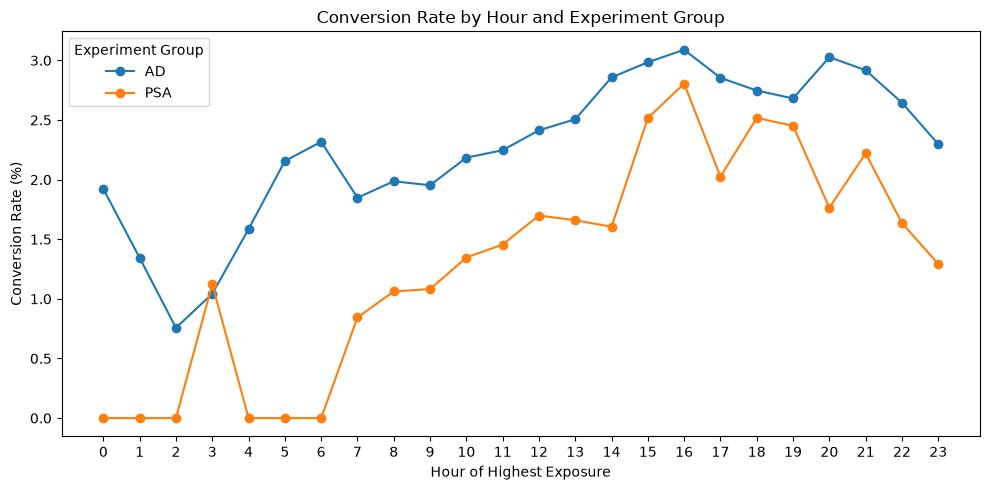

In [66]:
plt.figure(figsize=(10, 5))

for group in ["ad", "psa"]:
    subset = hour_summary[
        hour_summary["test group"] == group
    ]

    plt.plot(
        subset["most ads hour"],
        subset["conversion_rate_pct"],
        marker="o",
        label=group.upper()
    )

plt.xlabel("Hour of Highest Exposure")
plt.ylabel("Conversion Rate (%)")

plt.title(
    "Conversion Rate by Hour "
    "and Experiment Group"
)

plt.xticks(range(24))
plt.legend(title="Experiment Group")

plt.tight_layout()
plt.show()

### Hour-of-Day Patterns

Conversion rates varied by the hour of highest exposure.

During much of the daytime and evening, the advertising group maintained a higher observed conversion rate than the PSA group, broadly consistent with the primary experiment.

Several overnight PSA hours recorded zero conversions. These periods also contain relatively small control samples because only about 4% of users belong to the PSA group, so those hourly rates are considerably noisier than estimates from high-traffic periods.

As with day-of-week, `most ads hour` was not independently randomized. The observed timing patterns therefore cannot establish that delivering advertising at a particular hour causes higher conversion.

The appropriate next step would be a dedicated experiment that randomizes campaign timing.

## 6. Final Recommendation

### Experiment Conclusion

The advertising condition produced a clear improvement in the experiment's primary outcome:

- **PSA conversion rate:** 1.785%
- **Advertising conversion rate:** 2.555%
- **Absolute lift:** +0.769 percentage points
- **Relative lift:** +43.1%
- **95% CI for absolute lift:** +0.595 to +0.943 percentage points
- **Estimated incremental conversions:** approximately 4,343
- **95% CI for incremental conversions:** approximately 3,360 to 5,326

The statistical evidence strongly supports a positive difference between the advertising and PSA conditions.

### Business Recommendation

**Continue the advertising campaign if its actual economics fall below the break-even threshold implied by the incremental conversion value.**

The experiment demonstrates incremental conversion impact, but campaign costs and financial value per conversion are not available. For example, if each incremental conversion contributes $100 of business value, the estimated break-even campaign cost is approximately **$434,000**, with a more conservative threshold of approximately **$336,000** using the lower confidence bound.

The company should therefore compare its actual campaign cost and contribution value per conversion against the sensitivity analysis before making the final investment decision.

The exposure-frequency and timing analyses should **not** be used to immediately impose frequency caps or targeting schedules. Instead, they provide hypotheses for future controlled experiments.

## 7. Limitations & Recommended Follow-Up Experiments

### Limitations

1. **Campaign economics are unavailable.**  
   The dataset does not contain advertising cost, revenue, or contribution margin per conversion, so profitability cannot be directly estimated.

2. **The intended treatment-allocation probability is undocumented.**  
   The observed allocation is approximately 96% advertising and 4% PSA. Without the intended allocation ratio, a formal sample-ratio-mismatch test cannot be meaningfully interpreted.

3. **Limited pre-treatment user information is available.**  
   The dataset does not contain demographic, acquisition, or prior-behavior variables that could be used to independently inspect pre-treatment balance.

4. **Exposure frequency is post-assignment.**  
   `total ads` was not independently randomized, so the strong relationship between exposure count and conversion cannot be interpreted causally.

5. **Timing variables are also post-assignment.**  
   `most ads day` and `most ads hour` describe observed exposure patterns rather than randomized timing interventions.

6. **Small control samples occur in some exploratory segments.**  
   Because only about 4% of users belong to the PSA group, several narrow hourly or high-exposure segments contain relatively few control observations.

### Recommended Follow-Up Experiments

- **Randomized ad-frequency experiment:** Assign users to predefined exposure-frequency ranges to estimate diminishing returns and identify an economically efficient frequency cap.
- **Randomized timing experiment:** Randomize delivery windows to test whether campaign effectiveness genuinely differs by day or hour.
- **Economics-integrated experiment:** Record campaign spend and contribution value per conversion so future treatment effects can be translated directly into incremental profit and ROI.

## Executive Summary

A marketing A/B experiment involving **588,101 users** was analyzed to determine whether advertising generated incremental conversions relative to a PSA control.

Users assigned to advertising converted at **2.555%**, compared with **1.785%** for PSA, representing **0.769 percentage points of absolute lift** and a **43.1% relative improvement**.

The difference was statistically significant (**z = 7.37, p < 0.001**) with a 95% confidence interval of **0.595 to 0.943 percentage points**.

Applied to the advertising group, the estimated treatment effect corresponds to approximately **4,343 incremental conversions**, with a plausible range of approximately **3,360 to 5,326**.

Because campaign costs and financial value per conversion are unavailable, profitability cannot be directly calculated. A break-even sensitivity analysis shows how much the campaign could cost under different assumptions about the value of an incremental conversion.

Exploratory analyses found strong relationships between conversion, exposure frequency, and timing. However, those variables were not independently randomized, so they are treated as descriptive signals for future experiments rather than causal optimization recommendations.

**Recommendation:** Continue investment if actual campaign economics fall comfortably below the relevant break-even threshold, while using separate randomized experiments to optimize exposure frequency and campaign timing.

In [67]:
import sqlite3
import pandas as pd

# Load cleaned experiment data
clean_df = pd.read_csv("../data/processed/marketing_ab_clean.csv")

# Create SQLite database and write the experiment table
conn = sqlite3.connect("../data/processed/marketing_analytics.db")

clean_df.to_sql(
    "marketing_ab",
    conn,
    if_exists="replace",
    index=False
)

# Verify the table was created
check = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT "user id") AS unique_users
    FROM marketing_ab
    """,
    conn
)

display(check)

conn.close()

,rows,unique_users
0,588101,588101
